# Proyecto #2 Maze Solver

**Fernando Hernández 23645**

## Objetivo
Implementar y comparar BFS, DFS, Greedy First Search y A* para resolver laberintos de 128×128.
Se analizan: longitud del camino, nodos explorados, tiempo de ejecución y branching factor.

## Representación del laberinto
El laberinto es un archivo `.txt` donde:
- `'0'` → camino libre
- `'1'` → pared
- `'2'` → punto de partida
- `'3'` → punto de salida

**Jerarquía de movimientos:** Arriba → Derecha → Abajo → Izquierda

## 1. Utilidades: carga, visualización y funciones comunes


In [1]:
import time
import random
import heapq
import math
import copy
from collections import deque

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Jerarquía de movimientos: Arriba, Derecha, Abajo, Izquierda
MOVIMIENTOS = [(-1, 0), (0, 1), (1, 0), (0, -1)]


def cargar_laberinto(ruta: str) -> list[list[str]]:
    # Lee un archivo .txt y retorna una matriz 2-D de caracteres.
    # Cada carácter puede ser '0', '1', '2' o '3'.
    laberinto = []
    with open(ruta, 'r') as f:
        for linea in f:
            fila = list(linea.rstrip('\n'))
            if fila:                          # ignorar líneas vacías
                laberinto.append(fila)
    return laberinto


def encontrar_celdas(laberinto: list[list[str]], valor: str) -> list[tuple[int,int]]:
    # Retorna todas las posiciones (fila, col) que contienen `valor`.
    posiciones = []
    for r, fila in enumerate(laberinto):
        for c, celda in enumerate(fila):
            if celda == valor:
                posiciones.append((r, c))
    return posiciones


def es_transitable(laberinto: list[list[str]], r: int, c: int) -> bool:
    # Retorna True si la celda (r,c) existe y no es pared ('1').
    filas = len(laberinto)
    cols  = len(laberinto[0]) if filas else 0
    return 0 <= r < filas and 0 <= c < cols and laberinto[r][c] != '1'


def reconstruir_camino(padres: dict, inicio: tuple, fin: tuple) -> list[tuple]:
    # Sigue el diccionario de padres desde `fin` hasta `inicio`
    # y retorna la lista de nodos del camino (incluyendo ambos extremos).
    camino = []
    nodo = fin
    while nodo is not None:
        camino.append(nodo)
        nodo = padres.get(nodo)
    camino.reverse()
    return camino


# Heurísticas
def manhattan(a: tuple, b: tuple) -> float:
    # Distancia de Manhattan entre dos celdas.
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def euclidiana(a: tuple, b: tuple) -> float:
    # Distancia euclidiana entre dos celdas.
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)


print("Utilidades cargadas correctamente.")

Utilidades cargadas correctamente.


## 2. Visualización del laberinto


In [2]:
def visualizar_laberinto(laberinto: list[list[str]],
                         camino: list[tuple] = None,
                         visitados: set = None,
                         titulo: str = "Laberinto",
                         figsize: tuple = (10, 10)) -> None:
    # Dibuja el laberinto con matplotlib.

    # Colores:
    # Blanco  → camino libre (0)
    # Negro   → pared (1)
    # Verde   → inicio (2)
    # Rojo    → salida (3)
    # Celeste → nodos visitados
    # Amarillo→ camino solución
    filas = len(laberinto)
    cols  = len(laberinto[0])

    # Codificación numérica para colormap
    # 0=libre, 1=pared, 2=inicio, 3=salida, 4=visitado, 5=camino
    grid = np.zeros((filas, cols), dtype=int)
    for r in range(filas):
        for c in range(cols):
            v = laberinto[r][c]
            if   v == '1': grid[r, c] = 1
            elif v == '2': grid[r, c] = 2
            elif v == '3': grid[r, c] = 3

    if visitados:
        for (r, c) in visitados:
            if grid[r, c] == 0:
                grid[r, c] = 4

    if camino:
        for (r, c) in camino:
            if grid[r, c] not in (2, 3):
                grid[r, c] = 5

    colores = ['white', 'black', 'limegreen', 'red', 'lightblue', 'yellow']
    cmap = mcolors.ListedColormap(colores)
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
    norm   = mcolors.BoundaryNorm(bounds, cmap.N)

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(grid, cmap=cmap, norm=norm, interpolation='nearest')
    ax.set_title(titulo, fontsize=14)
    ax.axis('off')

    # Leyenda
    from matplotlib.patches import Patch
    leyenda = [
        Patch(color='limegreen',  label='Inicio'),
        Patch(color='red',        label='Salida'),
        Patch(color='lightblue',  label='Visitado'),
        Patch(color='yellow',     label='Camino solución'),
    ]
    ax.legend(handles=leyenda, loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()


print("Función de visualización lista.")

Función de visualización lista.


## 3. Algoritmos de búsqueda

Todos los algoritmos comparten la misma firma:

```
algoritmo(laberinto, inicio, fin) → (camino, nodos_explorados, tiempo_ms)
```

- `camino`: lista de celdas desde inicio hasta fin (vacía si no hay solución)
- `nodos_explorados`: cantidad de nodos extraídos de la frontera
- `tiempo_ms`: tiempo de ejecución en milisegundos

### 3.1 BFS Breadth-First Search

Explora nivel a nivel usando una **cola FIFO**.
Garantiza la solución de **menor número de pasos** (camino óptimo en grafos sin costo).

In [3]:
def bfs(laberinto: list[list[str]],
        inicio: tuple,
        fin: tuple) -> tuple[list, int, float]:
    # Breadth-First Search.

    # Parámetros:
    # laberinto : matriz 2-D de caracteres
    # inicio    : (fila, col) del punto de partida
    # fin       : (fila, col) del punto de salida

    # Retorna:
    # camino            : lista de celdas (vacía si no hay solución)
    # nodos_explorados  : entero
    # tiempo_ms         : float
    t0 = time.perf_counter()

    frontera = deque([inicio])          # cola FIFO
    padres   = {inicio: None}          # nodo → padre
    nodos_explorados = 0

    while frontera:
        actual = frontera.popleft()
        nodos_explorados += 1

        if actual == fin:
            camino = reconstruir_camino(padres, inicio, fin)
            return camino, nodos_explorados, (time.perf_counter() - t0) * 1000

        for dr, dc in MOVIMIENTOS:
            vecino = (actual[0] + dr, actual[1] + dc)
            if vecino not in padres and es_transitable(laberinto, *vecino):
                padres[vecino] = actual
                frontera.append(vecino)

    return [], nodos_explorados, (time.perf_counter() - t0) * 1000


print("BFS definido.")

BFS definido.


### 3.2 DFS Depth-First Search

Explora en profundidad usando una **pila LIFO**.
No garantiza la solución óptima, pero consume menos memoria que BFS en grafos profundos.

In [4]:
def dfs(laberinto: list[list[str]],
        inicio: tuple,
        fin: tuple) -> tuple[list, int, float]:
    # Depth-First Search (iterativo con pila explícita).

    # Parámetros:
    # laberinto : matriz 2-D de caracteres
    # inicio    : (fila, col) del punto de partida
    # fin       : (fila, col) del punto de salida

    # Retorna:
    # camino            : lista de celdas (vacía si no hay solución)
    # nodos_explorados  : entero
    # tiempo_ms         : float
    t0 = time.perf_counter()

    pila    = [inicio]
    padres  = {inicio: None}
    nodos_explorados = 0

    while pila:
        actual = pila.pop()             # LIFO
        nodos_explorados += 1

        if actual == fin:
            camino = reconstruir_camino(padres, inicio, fin)
            return camino, nodos_explorados, (time.perf_counter() - t0) * 1000

        # Insertar vecinos en orden inverso para respetar la jerarquía
        for dr, dc in reversed(MOVIMIENTOS):
            vecino = (actual[0] + dr, actual[1] + dc)
            if vecino not in padres and es_transitable(laberinto, *vecino):
                padres[vecino] = actual
                pila.append(vecino)

    return [], nodos_explorados, (time.perf_counter() - t0) * 1000


print("DFS definido.")

DFS definido.


### 3.3 Greedy First Search

Usa una **cola de prioridad** ordenada únicamente por la heurística `h(n)`.
Avanza rápido hacia la meta pero **no garantiza optimalidad**.
Se prueba con distancia Manhattan y euclidiana.

In [5]:
def greedy(laberinto: list[list[str]],
           inicio: tuple,
           fin: tuple,
           heuristica=manhattan) -> tuple[list, int, float]:
    # Greedy Best-First Search.

    # Parámetros:
    # laberinto  : matriz 2-D de caracteres
    # inicio     : (fila, col) del punto de partida
    # fin        : (fila, col) del punto de salida
    # heuristica : función h(nodo, fin) → float (por defecto Manhattan)

    # Retorna:
    # camino            : lista de celdas (vacía si no hay solución)
    # nodos_explorados  : entero
    # tiempo_ms         : float
    t0 = time.perf_counter()

    # Heap: (h, contador_desempate, nodo)
    contador = 0
    frontera = [(heuristica(inicio, fin), contador, inicio)]
    padres   = {inicio: None}
    nodos_explorados = 0

    while frontera:
        _, _, actual = heapq.heappop(frontera)
        nodos_explorados += 1

        if actual == fin:
            camino = reconstruir_camino(padres, inicio, fin)
            return camino, nodos_explorados, (time.perf_counter() - t0) * 1000

        for dr, dc in MOVIMIENTOS:
            vecino = (actual[0] + dr, actual[1] + dc)
            if vecino not in padres and es_transitable(laberinto, *vecino):
                padres[vecino] = actual
                contador += 1
                heapq.heappush(frontera, (heuristica(vecino, fin), contador, vecino))

    return [], nodos_explorados, (time.perf_counter() - t0) * 1000


print("Greedy definido.")

Greedy definido.


### 3.4 A*

Combina el costo real acumulado `g(n)` con la heurística `h(n)`: `f(n) = g(n) + h(n)`.
Con heurísticas **admisibles** (como Manhattan y euclidiana en grillas sin costos variables)
garantiza encontrar el **camino óptimo**.

In [6]:
def a_star(laberinto: list[list[str]],
           inicio: tuple,
           fin: tuple,
           heuristica=manhattan) -> tuple[list, int, float]:
    # A* Search.

    # Parámetros:
    # laberinto  : matriz 2-D de caracteres
    # inicio     : (fila, col) del punto de partida
    # fin        : (fila, col) del punto de salida
    # heuristica : función h(nodo, fin) → float (por defecto Manhattan)

    # Retorna:
    # camino            : lista de celdas (vacía si no hay solución)
    # nodos_explorados  : entero
    # tiempo_ms         : float
    t0 = time.perf_counter()

    # Heap: (f, contador_desempate, nodo)
    contador = 0
    frontera = [(heuristica(inicio, fin), contador, inicio)]
    padres   = {inicio: None}
    g        = {inicio: 0}             # costo acumulado desde inicio
    nodos_explorados = 0

    while frontera:
        f_actual, _, actual = heapq.heappop(frontera)
        nodos_explorados += 1

        if actual == fin:
            camino = reconstruir_camino(padres, inicio, fin)
            return camino, nodos_explorados, (time.perf_counter() - t0) * 1000

        for dr, dc in MOVIMIENTOS:
            vecino = (actual[0] + dr, actual[1] + dc)
            if not es_transitable(laberinto, *vecino):
                continue

            g_nuevo = g[actual] + 1    # costo uniforme: cada paso cuesta 1

            if vecino not in g or g_nuevo < g[vecino]:
                g[vecino]      = g_nuevo
                padres[vecino] = actual
                f_nuevo        = g_nuevo + heuristica(vecino, fin)
                contador += 1
                heapq.heappush(frontera, (f_nuevo, contador, vecino))

    return [], nodos_explorados, (time.perf_counter() - t0) * 1000


print("A* definido.")

A* definido.


## 4. Carga del laberinto y prueba rápida


Dimensiones: 64 filas × 64 columnas
Inicio(s): [(1, 1)]
Salida(s): [(43, 47)]


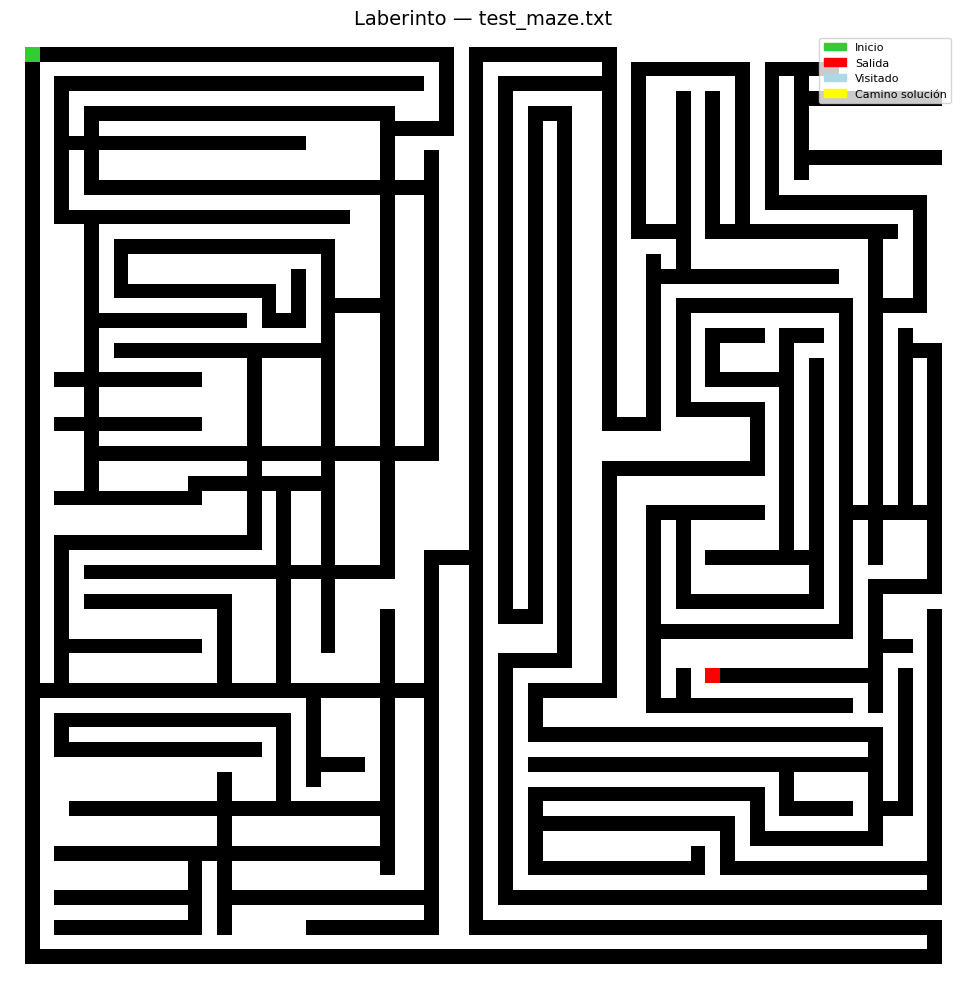

In [7]:
# Ruta al archivo de texto del laberinto
RUTA_LABERINTO = "test_maze.txt"

laberinto = cargar_laberinto(RUTA_LABERINTO)
print(f"Dimensiones: {len(laberinto)} filas × {len(laberinto[0])} columnas")

inicios = encontrar_celdas(laberinto, '2')
salidas = encontrar_celdas(laberinto, '3')
print(f"Inicio(s): {inicios}")
print(f"Salida(s): {salidas}")

# Caso base: primer inicio y primera salida marcados en el archivo
INICIO_BASE = inicios[0]
FIN_BASE    = salidas[0]

# Visualización del laberinto vacío
visualizar_laberinto(laberinto, titulo=f"Laberinto — {RUTA_LABERINTO}")

## 5. Caso base ejecución de todos los algoritmos


In [8]:
def calcular_branching_factor(nodos: int, profundidad: int,
                               tolerancia: float = 1e-4,
                               max_iter: int = 100) -> float:
    # Estima el branching factor efectivo b* resolviendo numéricamente:
    #     1 + b + b^2 + ... + b^d = N  mediante búsqueda binaria.
    if profundidad <= 0 or nodos <= 1:
        return 1.0

    def suma_geometrica(b, d):
        if abs(b - 1.0) < 1e-9:
            return float(d + 1)
        try:
            return (b**(d + 1) - 1) / (b - 1)
        except OverflowError:
            return float('inf')

    lo, hi = 1.0, float(nodos)
    for _ in range(max_iter):
        mid = (lo + hi) / 2
        val = suma_geometrica(mid, profundidad)
        if abs(val - nodos) < tolerancia:
            return mid
        if val < nodos:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2

# Configuración de algoritmos a ejecutar
configuraciones = [
    ("BFS",                 lambda lab, s, e: bfs(lab, s, e)),
    ("DFS",                 lambda lab, s, e: dfs(lab, s, e)),
    ("Greedy (Manhattan)",  lambda lab, s, e: greedy(lab, s, e, manhattan)),
    ("Greedy (Euclidiana)", lambda lab, s, e: greedy(lab, s, e, euclidiana)),
    ("A* (Manhattan)",      lambda lab, s, e: a_star(lab, s, e, manhattan)),
    ("A* (Euclidiana)",     lambda lab, s, e: a_star(lab, s, e, euclidiana)),
]

print("=== Caso base ===")
print(f"Inicio: {INICIO_BASE}  →  Fin: {FIN_BASE}\n")

resultados_base = []

for nombre, fn in configuraciones:
    camino, nodos, t_ms = fn(laberinto, INICIO_BASE, FIN_BASE)
    largo = len(camino) - 1 if camino else 0    # número de pasos (aristas)
    bf    = calcular_branching_factor(nodos, largo)
    encontro = bool(camino)
    resultados_base.append({
        "algoritmo": nombre,
        "encontro":  encontro,
        "largo":     largo,
        "nodos":     nodos,
        "tiempo_ms": t_ms,
        "bf":        bf,
        "camino":    camino,
    })
    estado = "✓" if encontro else "✗"
    print(f"{estado} {nombre:<25} pasos={largo:>5}  nodos={nodos:>7}  "
          f"tiempo={t_ms:>8.3f} ms  BF≈{bf:.4f}")

=== Caso base ===
Inicio: (1, 1)  →  Fin: (43, 47)

✓ BFS                       pasos=  128  nodos=    665  tiempo=   1.629 ms  BF≈1.0213
✓ DFS                       pasos=  128  nodos=    465  tiempo=   1.137 ms  BF≈1.0172
✓ Greedy (Manhattan)        pasos=  128  nodos=    240  tiempo=   0.493 ms  BF≈1.0089
✓ Greedy (Euclidiana)       pasos=  132  nodos=    402  tiempo=   0.885 ms  BF≈1.0146
✓ A* (Manhattan)            pasos=  128  nodos=    547  tiempo=   1.402 ms  BF≈1.0191
✓ A* (Euclidiana)           pasos=  128  nodos=    600  tiempo=   1.710 ms  BF≈1.0201


### 5.1 Visualización del caso base


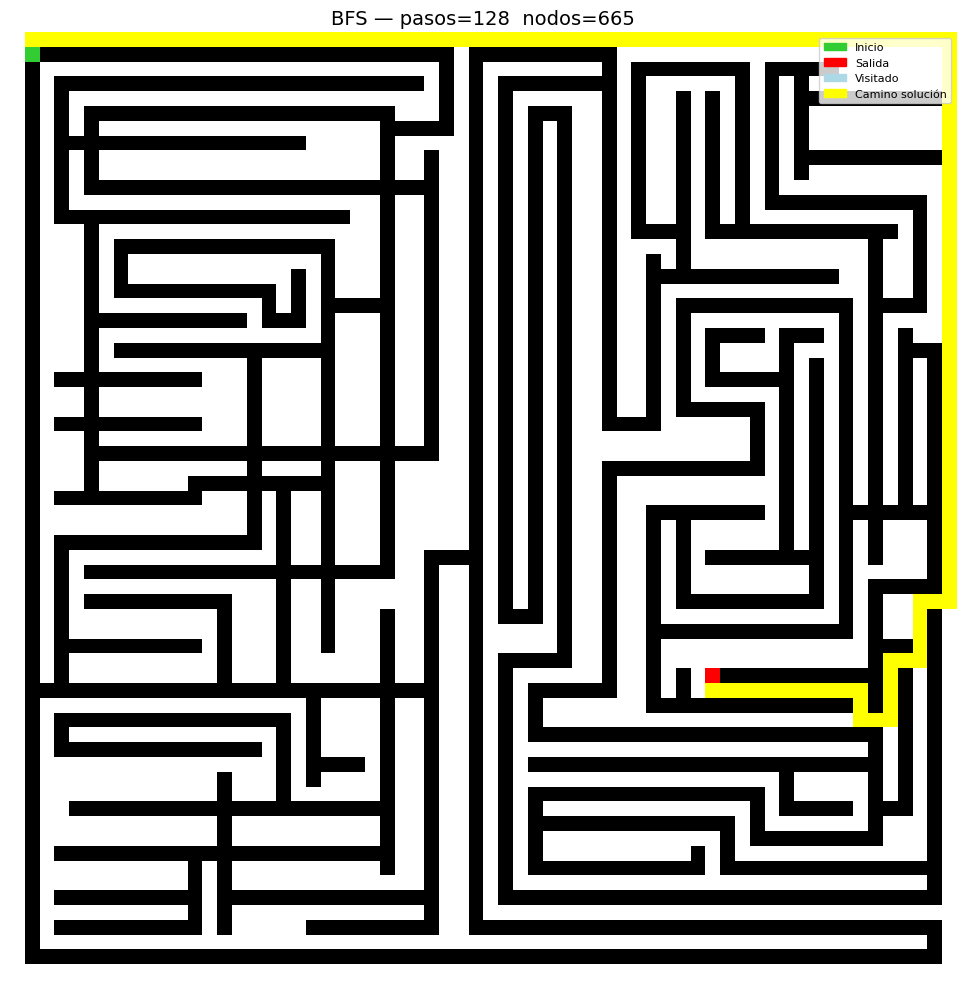

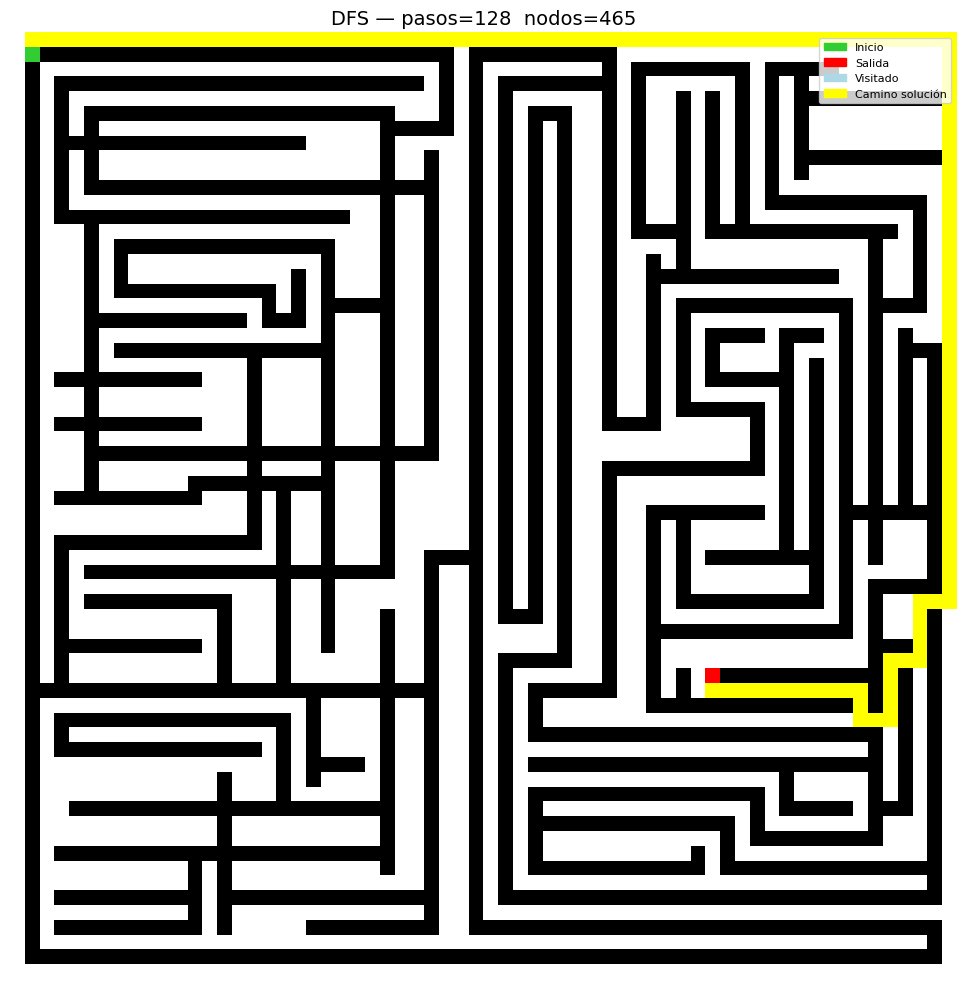

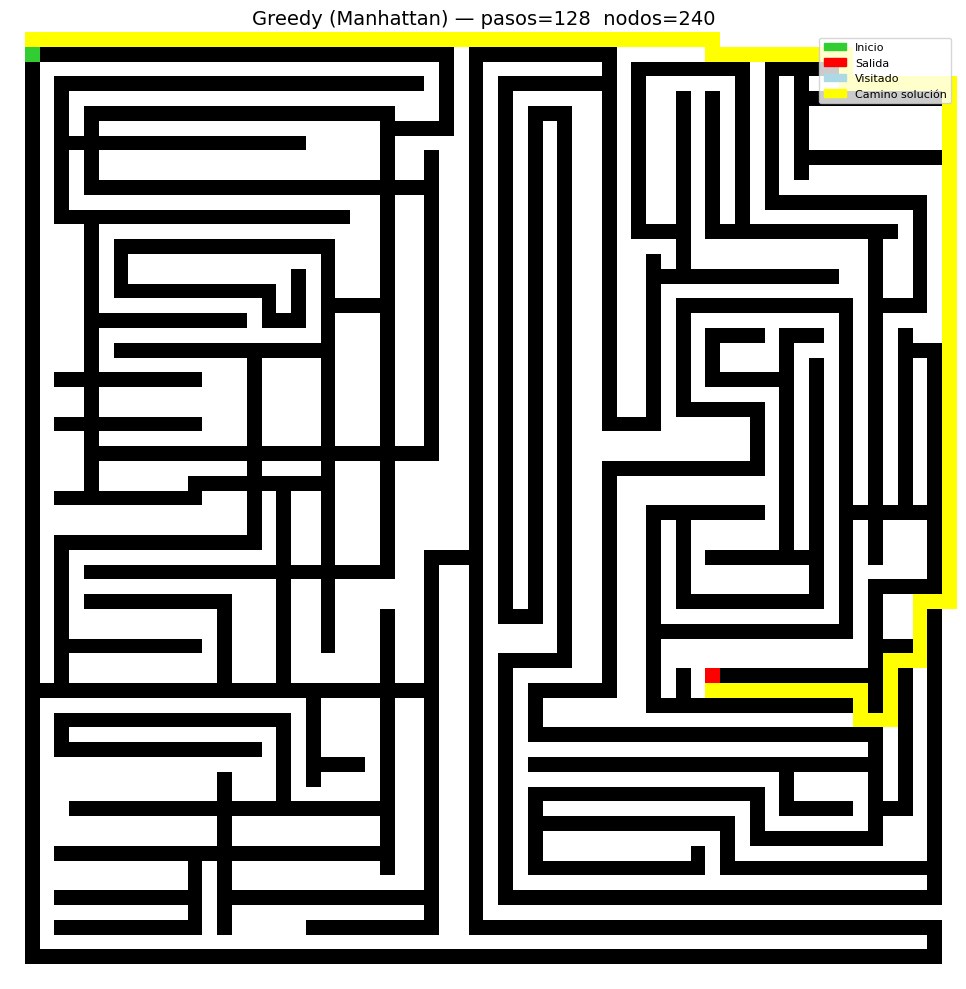

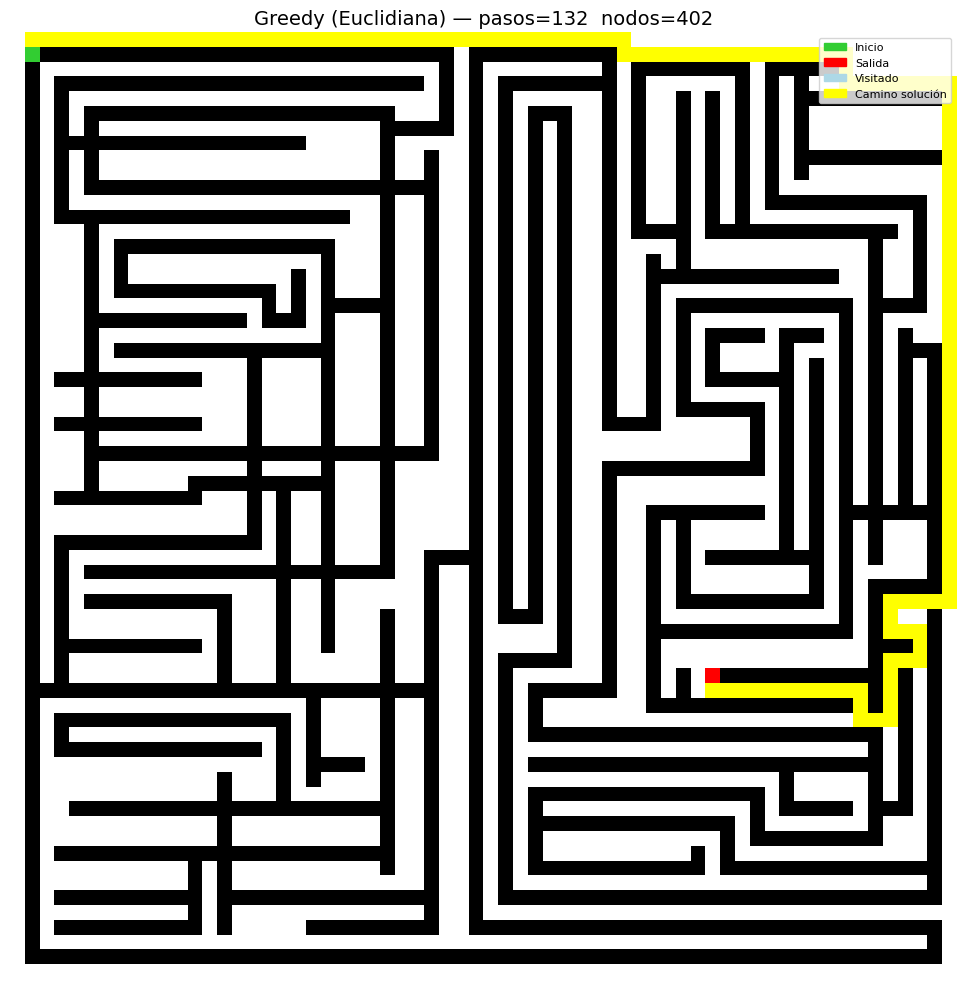

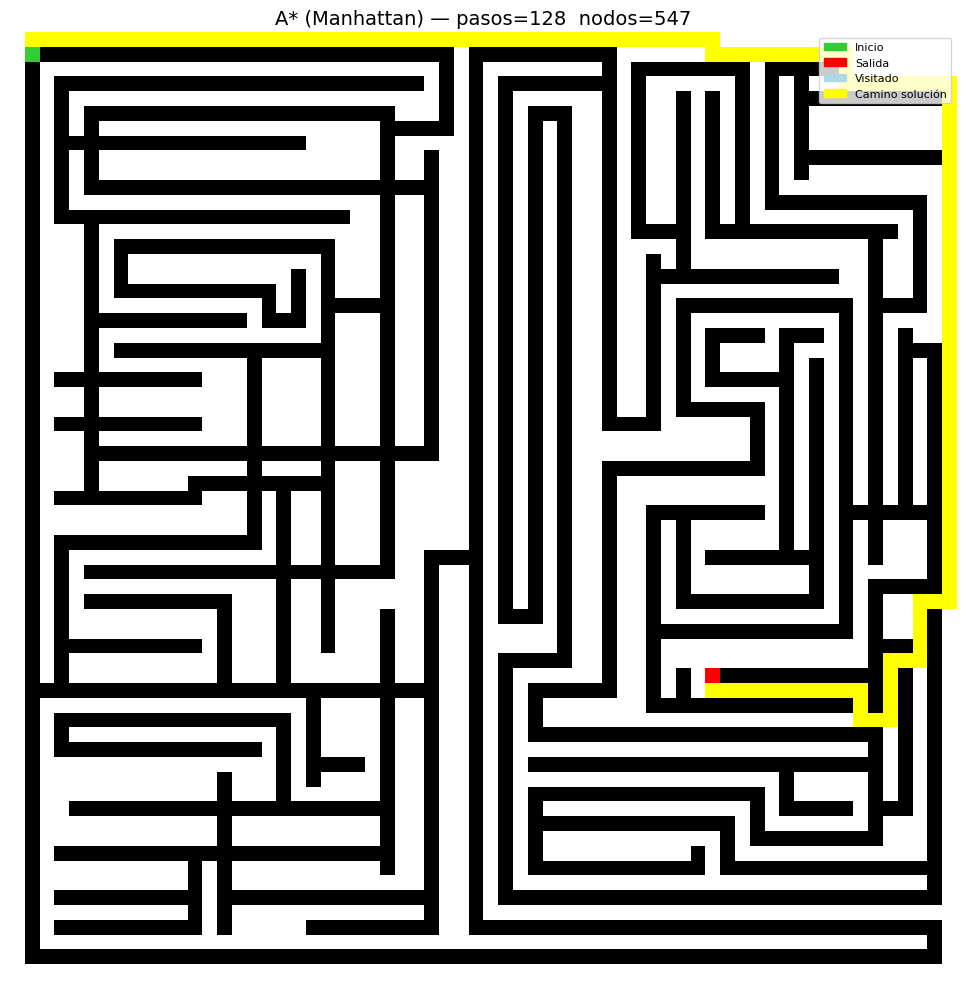

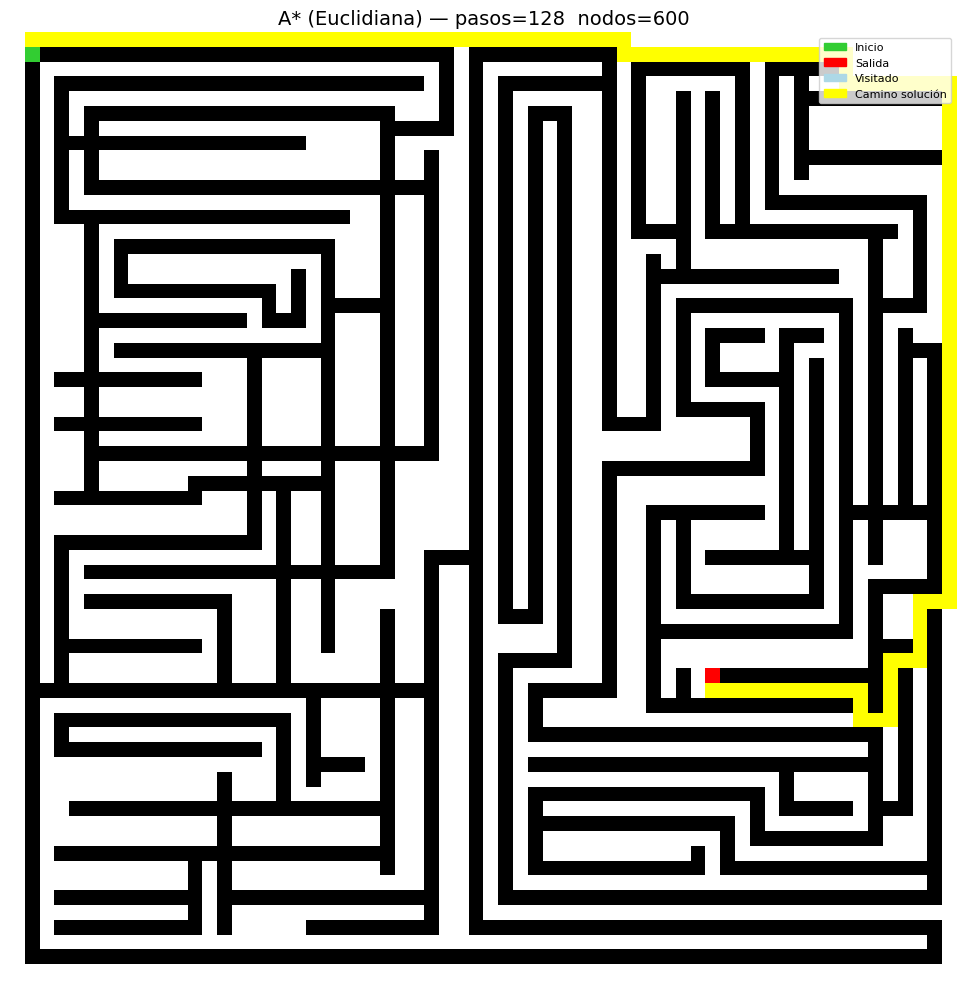

In [9]:
for r in resultados_base:
    visitados_set = set()   # (opcional: pasar el conjunto de nodos visitados)
    if r["camino"]:
        visualizar_laberinto(
            laberinto,
            camino=r["camino"],
            titulo=f"{r['algoritmo']} — pasos={r['largo']}  nodos={r['nodos']}"
        )

## 6. Simulación con puntos de partida aleatorios

Se seleccionan **N** puntos de inicio aleatorios entre las celdas transitables
del laberinto y se mide el rendimiento de cada algoritmo en promedio.

In [10]:
def celdas_libres(laberinto: list[list[str]]) -> list[tuple]:
    # Retorna todas las celdas transitables (valor != '1').
    libres = []
    for r, fila in enumerate(laberinto):
        for c, celda in enumerate(fila):
            if celda != '1':
                libres.append((r, c))
    return libres


def ejecutar_desde_inicio_aleatorio(laberinto, fin, fn_algoritmo,
                                     n_simulaciones=50,
                                     semilla=42) -> dict:
    # Ejecuta `fn_algoritmo` `n_simulaciones` veces con inicios aleatorios.

    # Retorna un diccionario con promedios de: largo, nodos, tiempo, BF.
    # Solo cuenta las ejecuciones que encontraron solución.
    random.seed(semilla)
    candidatos = celdas_libres(laberinto)
    # excluir la meta como inicio posible
    candidatos = [c for c in candidatos if c != fin]

    largos, nodos_list, tiempos, bfs_list = [], [], [], []
    exitos = 0

    for _ in range(n_simulaciones):
        inicio_rand = random.choice(candidatos)
        camino, nodos, t_ms = fn_algoritmo(laberinto, inicio_rand, fin)
        if camino:
            exitos += 1
            largo = len(camino) - 1
            largos.append(largo)
            nodos_list.append(nodos)
            tiempos.append(t_ms)
            bfs_list.append(calcular_branching_factor(nodos, largo))

    def avg(lst): return sum(lst) / len(lst) if lst else 0.0

    return {
        "exito_pct":      (exitos / n_simulaciones) * 100,
        "largo_prom":     avg(largos),
        "nodos_prom":     avg(nodos_list),
        "tiempo_prom_ms": avg(tiempos),
        "bf_prom":        avg(bfs_list),
    }


N_SIMULACIONES = 50   # ajustable

print(f"Ejecutando {N_SIMULACIONES} simulaciones con inicios aleatorios...\n")

resultados_aleatorios = []
for nombre, fn in configuraciones:
    stats = ejecutar_desde_inicio_aleatorio(
        laberinto, FIN_BASE, fn, n_simulaciones=N_SIMULACIONES
    )
    stats["algoritmo"] = nombre
    resultados_aleatorios.append(stats)
    print(f"  {nombre} → éxito={stats['exito_pct']:.0f}%  "
          f"largo={stats['largo_prom']:.1f}  "
          f"nodos={stats['nodos_prom']:.0f}  "
          f"t={stats['tiempo_prom_ms']:.3f}ms  "
          f"BF≈{stats['bf_prom']:.4f}")

print("\nSimulaciones completadas.")

Ejecutando 50 simulaciones con inicios aleatorios...

  BFS → éxito=50%  largo=80.8  nodos=361  t=0.562ms  BF≈1.0436
  DFS → éxito=50%  largo=137.0  nodos=546  t=0.847ms  BF≈1.0386
  Greedy (Manhattan) → éxito=50%  largo=81.6  nodos=153  t=0.320ms  BF≈1.0126
  Greedy (Euclidiana) → éxito=50%  largo=84.7  nodos=186  t=0.404ms  BF≈1.0227
  A* (Manhattan) → éxito=50%  largo=80.8  nodos=232  t=0.575ms  BF≈1.0252
  A* (Euclidiana) → éxito=50%  largo=80.8  nodos=255  t=0.859ms  BF≈1.0289

Simulaciones completadas.


## 7. Tabla comparativa de resultados


In [11]:
# Tabla caso base
print("=" * 90)
print("CASO BASE")
print("=" * 90)
encabezado = f"{'Algoritmo':<25} {'Pasos':>7} {'Nodos':>8} {'Tiempo (ms)':>12} {'BF efectivo':>12}"
print(encabezado)
print("-" * 90)
for r in resultados_base:
    print(f"{r['algoritmo']:<25} {r['largo']:>7} {r['nodos']:>8} "
          f"{r['tiempo_ms']:>12.3f} {r['bf']:>12.4f}")

print()
print("=" * 90)
print(f"INICIOS ALEATORIOS  (n={N_SIMULACIONES})")
print("=" * 90)
encabezado2 = (f"{'Algoritmo':<25} {'Éxito%':>7} {'Pasos prom':>11} "
               f"{'Nodos prom':>11} {'Tiempo prom (ms)':>17} {'BF prom':>9}")
print(encabezado2)
print("-" * 90)
for r in resultados_aleatorios:
    print(f"{r['algoritmo']:<25} {r['exito_pct']:>7.1f} {r['largo_prom']:>11.1f} "
          f"{r['nodos_prom']:>11.0f} {r['tiempo_prom_ms']:>17.3f} {r['bf_prom']:>9.4f}")

CASO BASE
Algoritmo                   Pasos    Nodos  Tiempo (ms)  BF efectivo
------------------------------------------------------------------------------------------
BFS                           128      665        1.629       1.0213
DFS                           128      465        1.137       1.0172
Greedy (Manhattan)            128      240        0.493       1.0089
Greedy (Euclidiana)           132      402        0.885       1.0146
A* (Manhattan)                128      547        1.402       1.0191
A* (Euclidiana)               128      600        1.710       1.0201

INICIOS ALEATORIOS  (n=50)
Algoritmo                  Éxito%  Pasos prom  Nodos prom  Tiempo prom (ms)   BF prom
------------------------------------------------------------------------------------------
BFS                          50.0        80.8         361             0.562    1.0436
DFS                          50.0       137.0         546             0.847    1.0386
Greedy (Manhattan)           50.0      

## 8. Gráficas comparativas


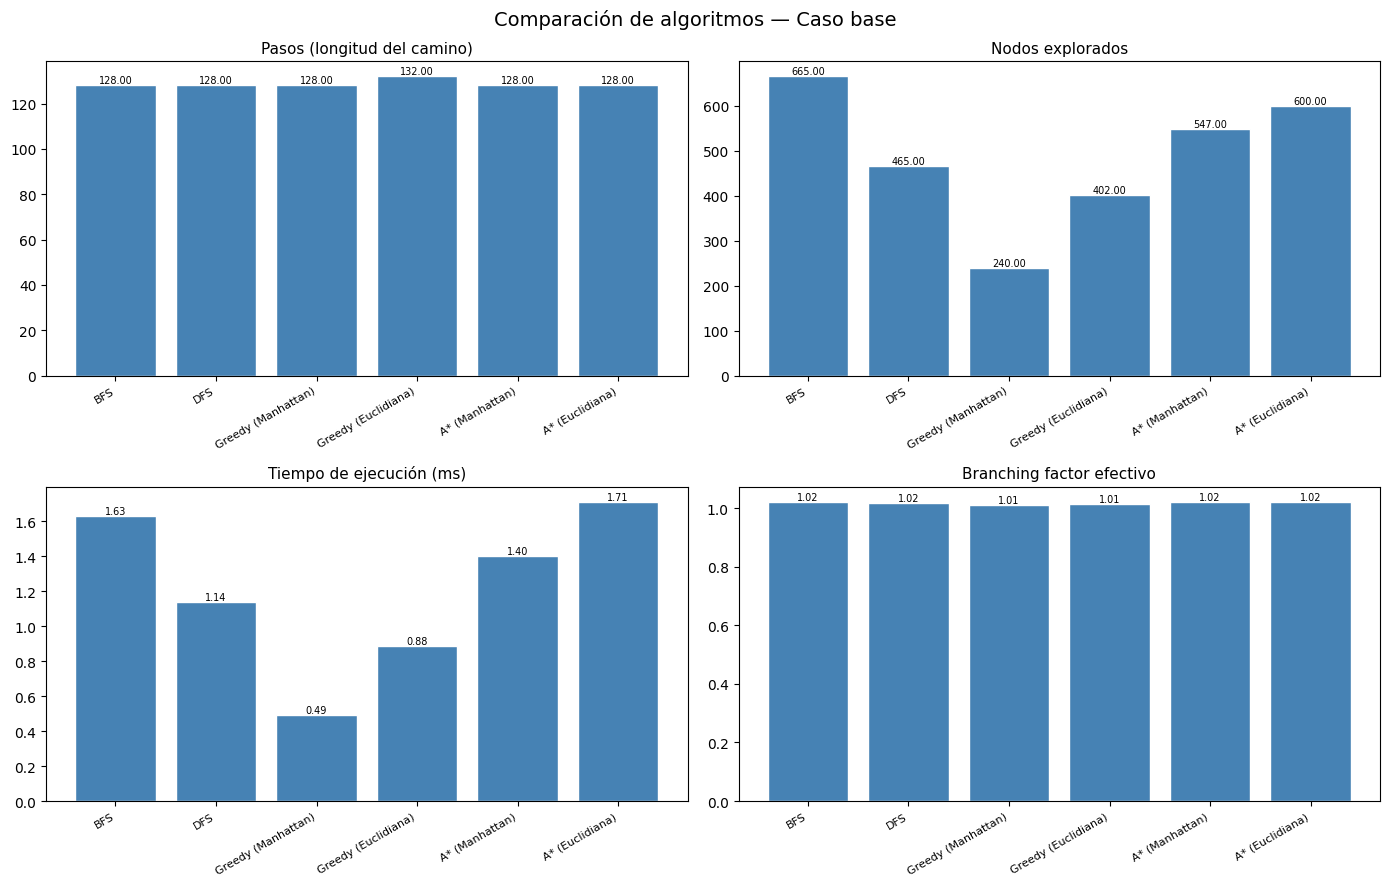

In [12]:
nombres_alg = [r["algoritmo"] for r in resultados_base]
x = np.arange(len(nombres_alg))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Comparación de algoritmos — Caso base", fontsize=14)

metricas = [
    ([r["largo"]     for r in resultados_base], "Pasos (longitud del camino)",  axes[0,0]),
    ([r["nodos"]     for r in resultados_base], "Nodos explorados",              axes[0,1]),
    ([r["tiempo_ms"] for r in resultados_base], "Tiempo de ejecución (ms)",     axes[1,0]),
    ([r["bf"]        for r in resultados_base], "Branching factor efectivo",     axes[1,1]),
]

for valores, etiqueta, ax in metricas:
    bars = ax.bar(x, valores, color='steelblue', edgecolor='white')
    ax.set_title(etiqueta, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(nombres_alg, rotation=30, ha='right', fontsize=8)
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{v:.2f}", ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

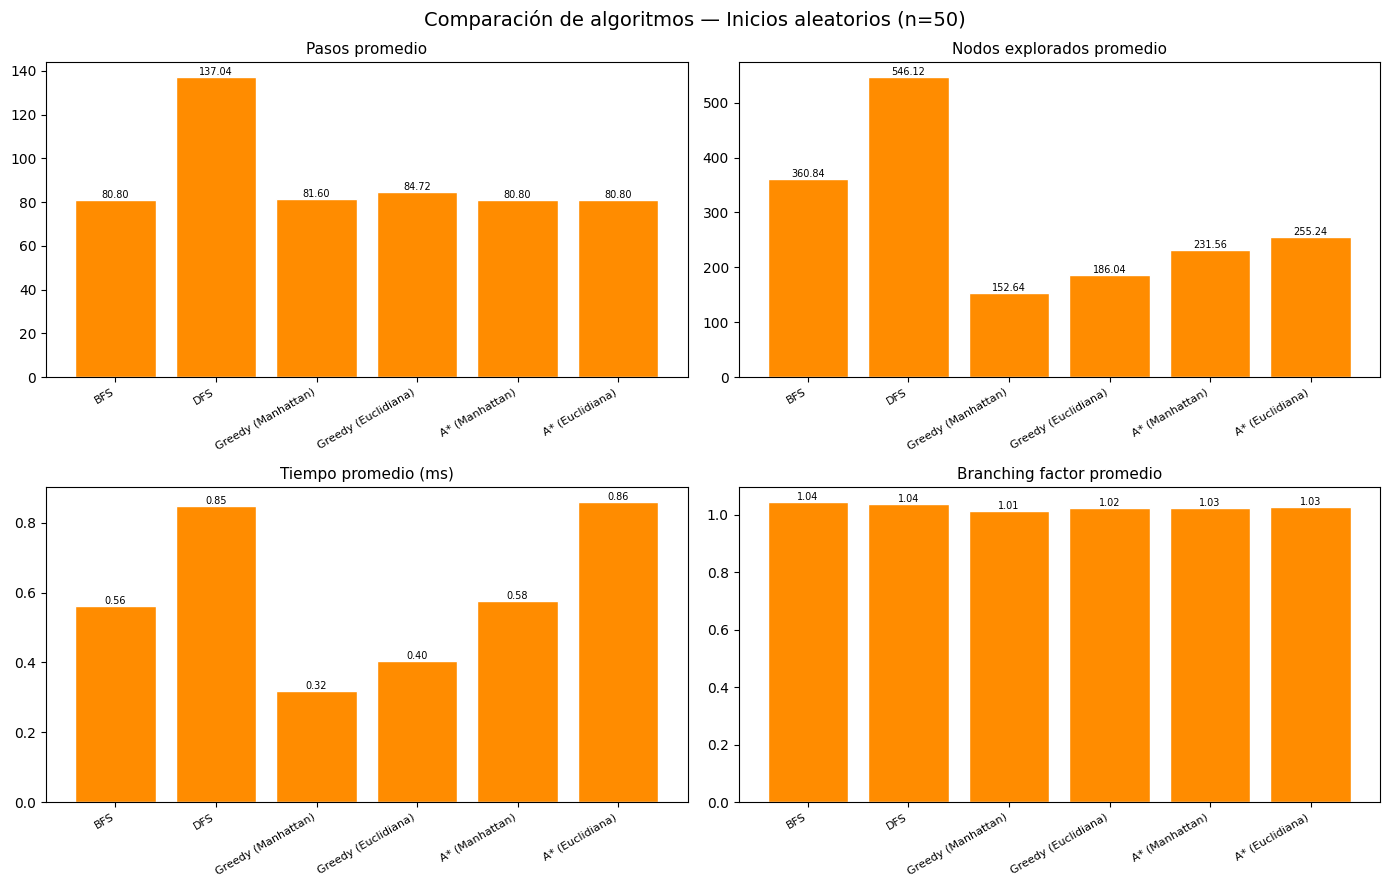

In [13]:
nombres_alg2 = [r["algoritmo"] for r in resultados_aleatorios]
x2 = np.arange(len(nombres_alg2))

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 9))
fig2.suptitle(f"Comparación de algoritmos — Inicios aleatorios (n={N_SIMULACIONES})", fontsize=14)

metricas2 = [
    ([r["largo_prom"]     for r in resultados_aleatorios], "Pasos promedio",                axes2[0,0]),
    ([r["nodos_prom"]     for r in resultados_aleatorios], "Nodos explorados promedio",     axes2[0,1]),
    ([r["tiempo_prom_ms"] for r in resultados_aleatorios], "Tiempo promedio (ms)",          axes2[1,0]),
    ([r["bf_prom"]        for r in resultados_aleatorios], "Branching factor promedio",     axes2[1,1]),
]

for valores, etiqueta, ax in metricas2:
    bars = ax.bar(x2, valores, color='darkorange', edgecolor='white')
    ax.set_title(etiqueta, fontsize=11)
    ax.set_xticks(x2)
    ax.set_xticklabels(nombres_alg2, rotation=30, ha='right', fontsize=8)
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{v:.2f}", ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

## 9. Presentación

Esta sección permite cargar un laberinto en tiempo de ejecución y ejecutar
todos los algoritmos.


Laberinto cargado: test_maze.txt
Dimensiones: 64 × 64
Inicio: (1, 1)   Salida: (43, 47)

Algoritmo                    Nodos   Pasos  Tiempo (ms)
----------------------------------------------------------
✓ BFS                          665     128        2.983


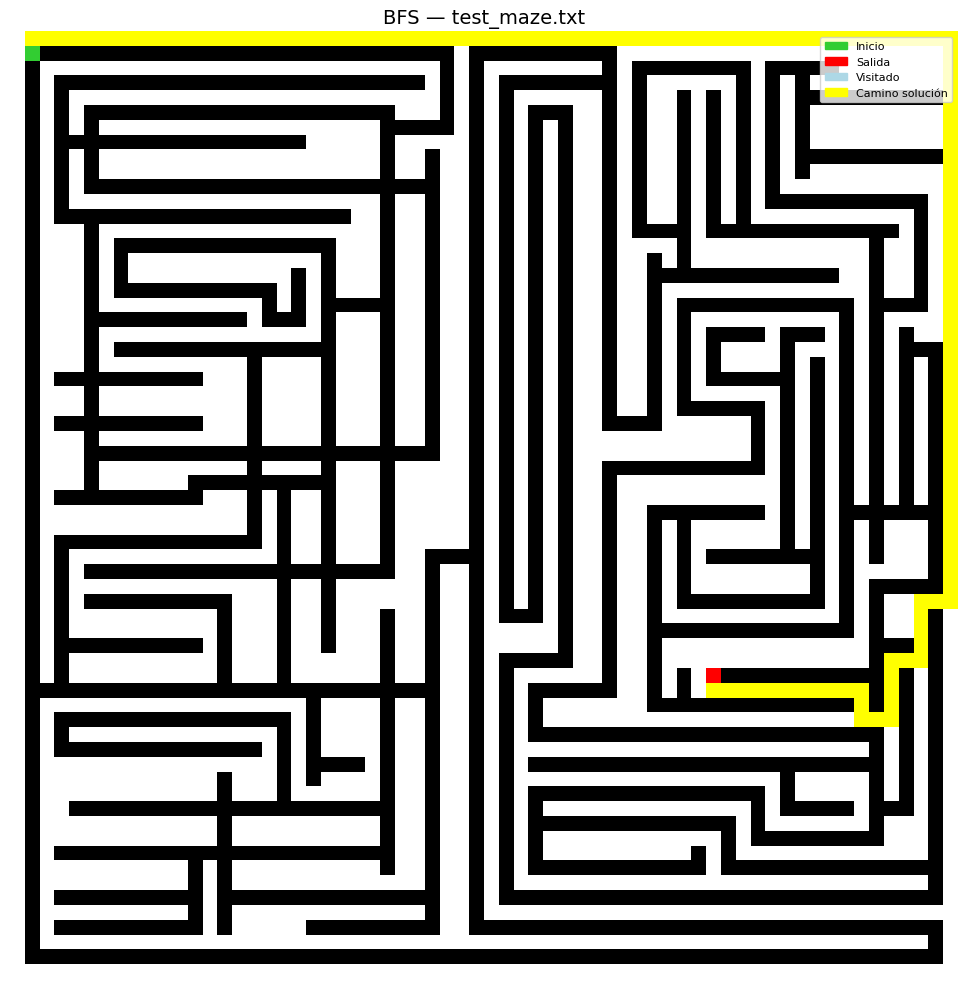

✓ DFS                          465     128        0.798


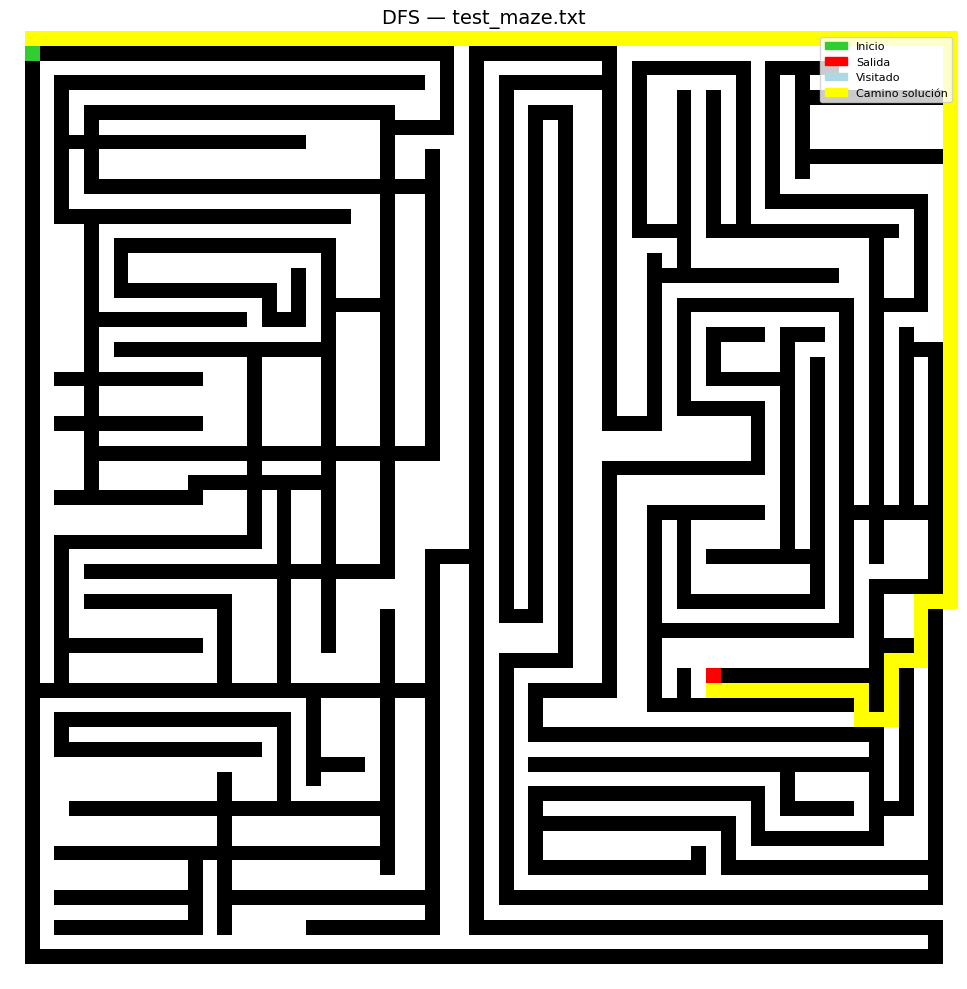

✓ Greedy (Manhattan)           240     128        0.592


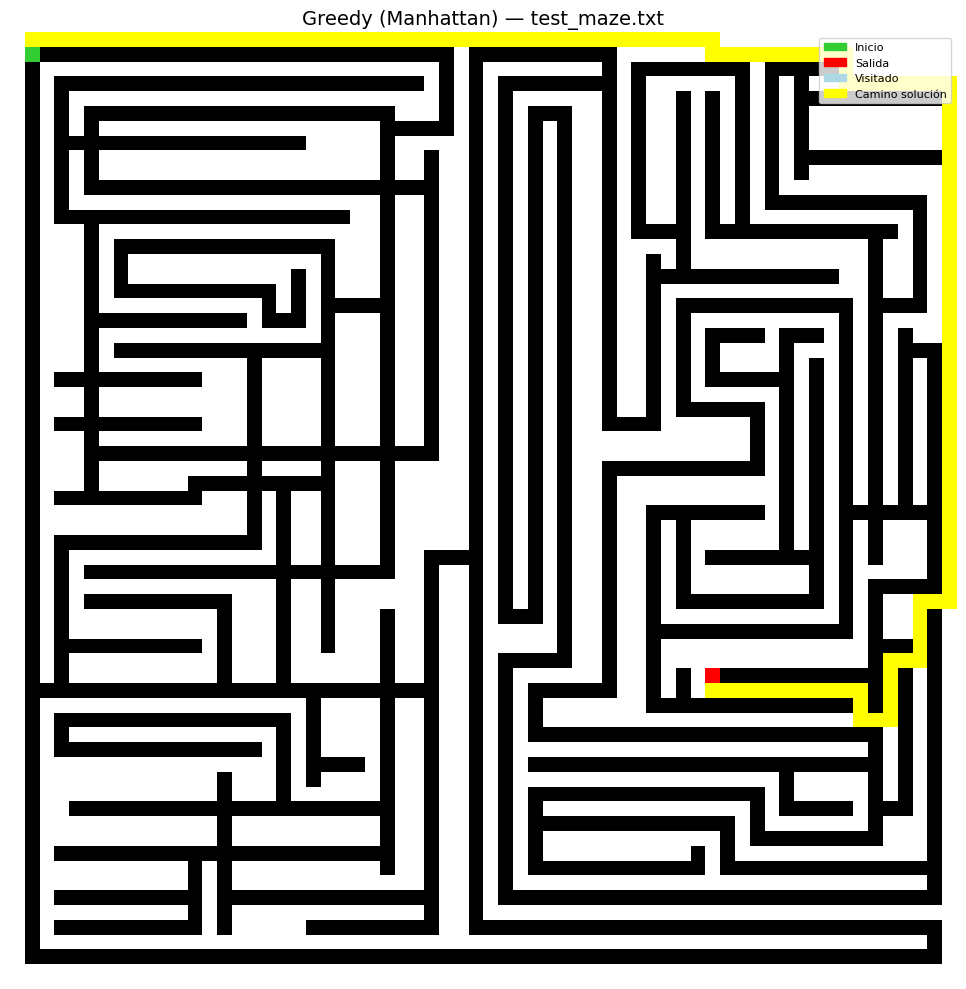

✓ Greedy (Euclidiana)          402     132        1.004


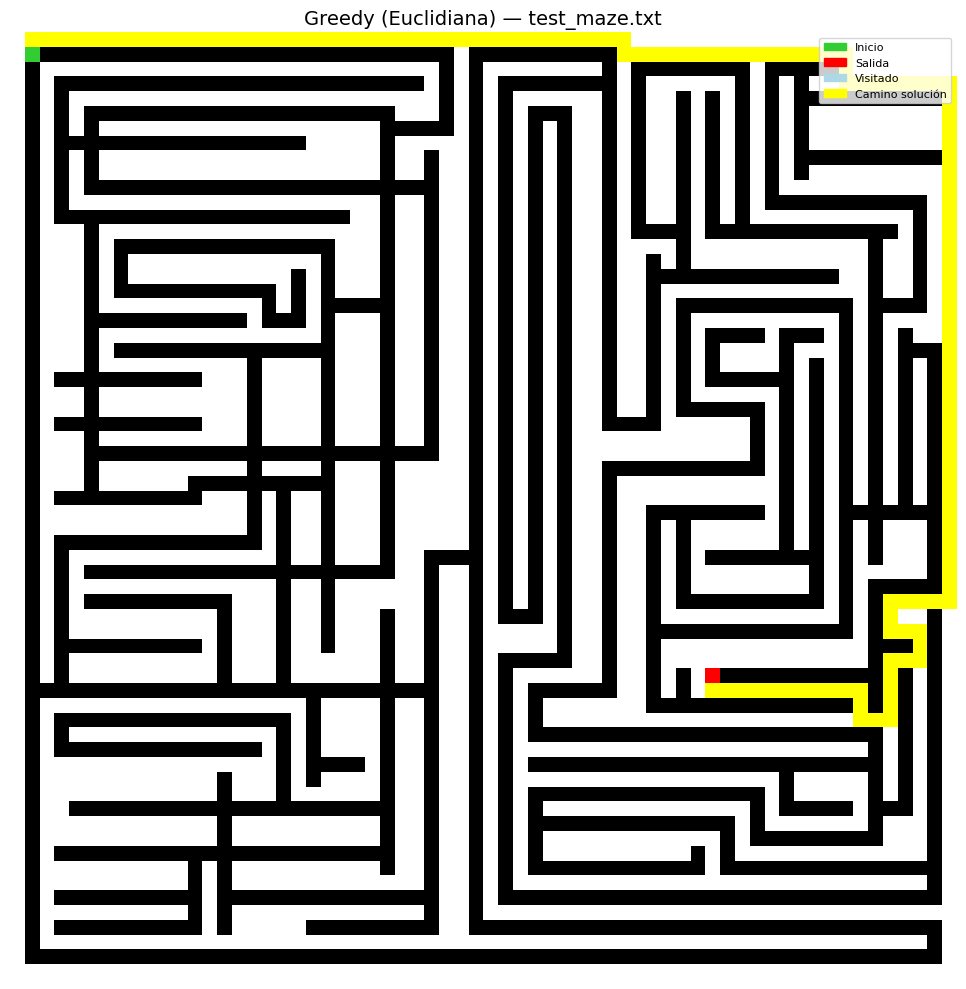

✓ A* (Manhattan)               547     128        2.029


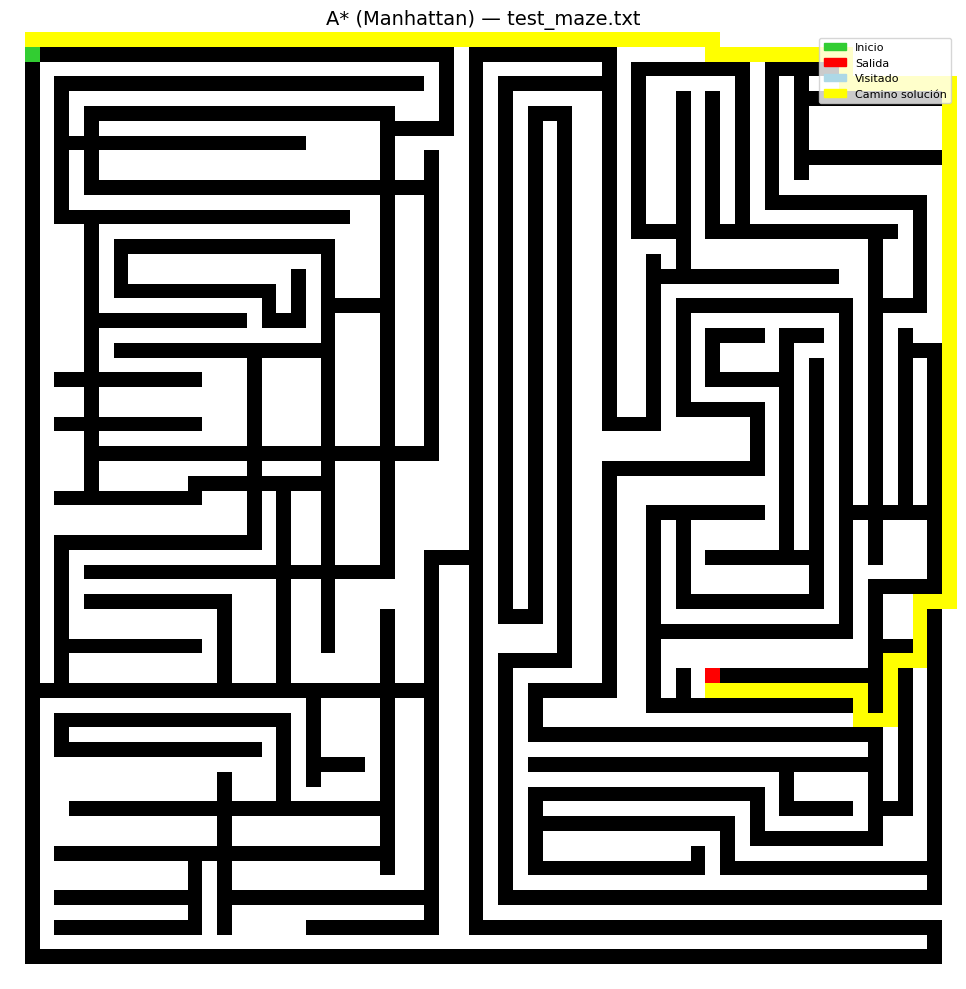

✓ A* (Euclidiana)              600     128        1.706


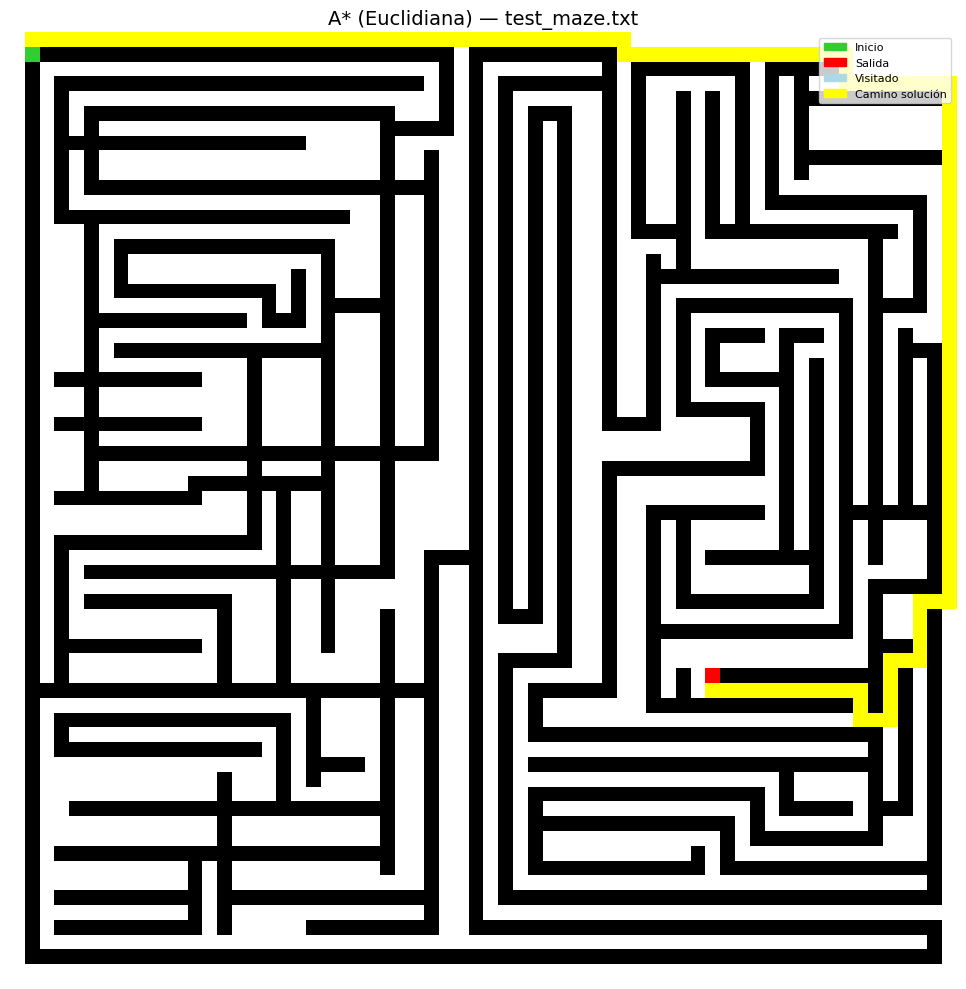

In [15]:
def resolver_laberinto_interactivo(ruta: str) -> None:
    # Carga el laberinto en `ruta`, ejecuta todos los algoritmos
    # y muestra: nodos visitados, largo del camino y tiempo de ejecución.
    # También visualización del camino tomado de cada algoritmo.
    lab = cargar_laberinto(ruta)
    print(f"\nLaberinto cargado: {ruta}")
    print(f"Dimensiones: {len(lab)} × {len(lab[0])}")

    inicios_ = encontrar_celdas(lab, '2')
    salidas_ = encontrar_celdas(lab, '3')
    if not inicios_ or not salidas_:
        print("ERROR: no se encontró inicio ('2') o salida ('3') en el laberinto.")
        return

    s, e = inicios_[0], salidas_[0]
    print(f"Inicio: {s}   Salida: {e}\n")

    print(f"{'Algoritmo':<25} {'Nodos':>8} {'Pasos':>7} {'Tiempo (ms)':>12}")
    print("-" * 58)

    for nombre, fn in configuraciones:
        camino, nodos, t_ms = fn(lab, s, e)
        largo = len(camino) - 1 if camino else 0
        estado = "✓" if camino else "✗ SIN SOLUCIÓN"
        print(f"{estado} {nombre:<23} {nodos:>8} {largo:>7} {t_ms:>12.3f}")

        if camino:
            visualizar_laberinto(
                lab,
                camino=camino,
                titulo=f"{nombre} — {ruta}"
            )


# Llamadas de ejemplo
resolver_laberinto_interactivo("test_maze.txt")
